In [201]:
import wfdb
import numpy as np
import pandas as pd
import neurokit2 as nk
from scipy.signal import butter, filtfilt

In [202]:
# Remove any noise
def bandpass_filter(signal, low=0.2, high=40, fs=100):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

In [203]:
# Load the metadata dataset
metadata = pd.read_csv("metadata.csv")
metadata.head()

,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


Preprocessing

In [204]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   patient_id     363 non-null    int64
 1   basal_pattern  363 non-null    int64
 2   sudden_death   363 non-null    int64
 3   brugada        363 non-null    int64
dtypes: int64(4)
memory usage: 11.5 KB


In [205]:
# Data Loading
patient_id = str(metadata.iloc[0]["patient_id"])
record_path = f"files/{patient_id}/{patient_id}"

record = wfdb.rdrecord(record_path)
signal = record.p_signal

print(signal.shape)

(1200, 12)


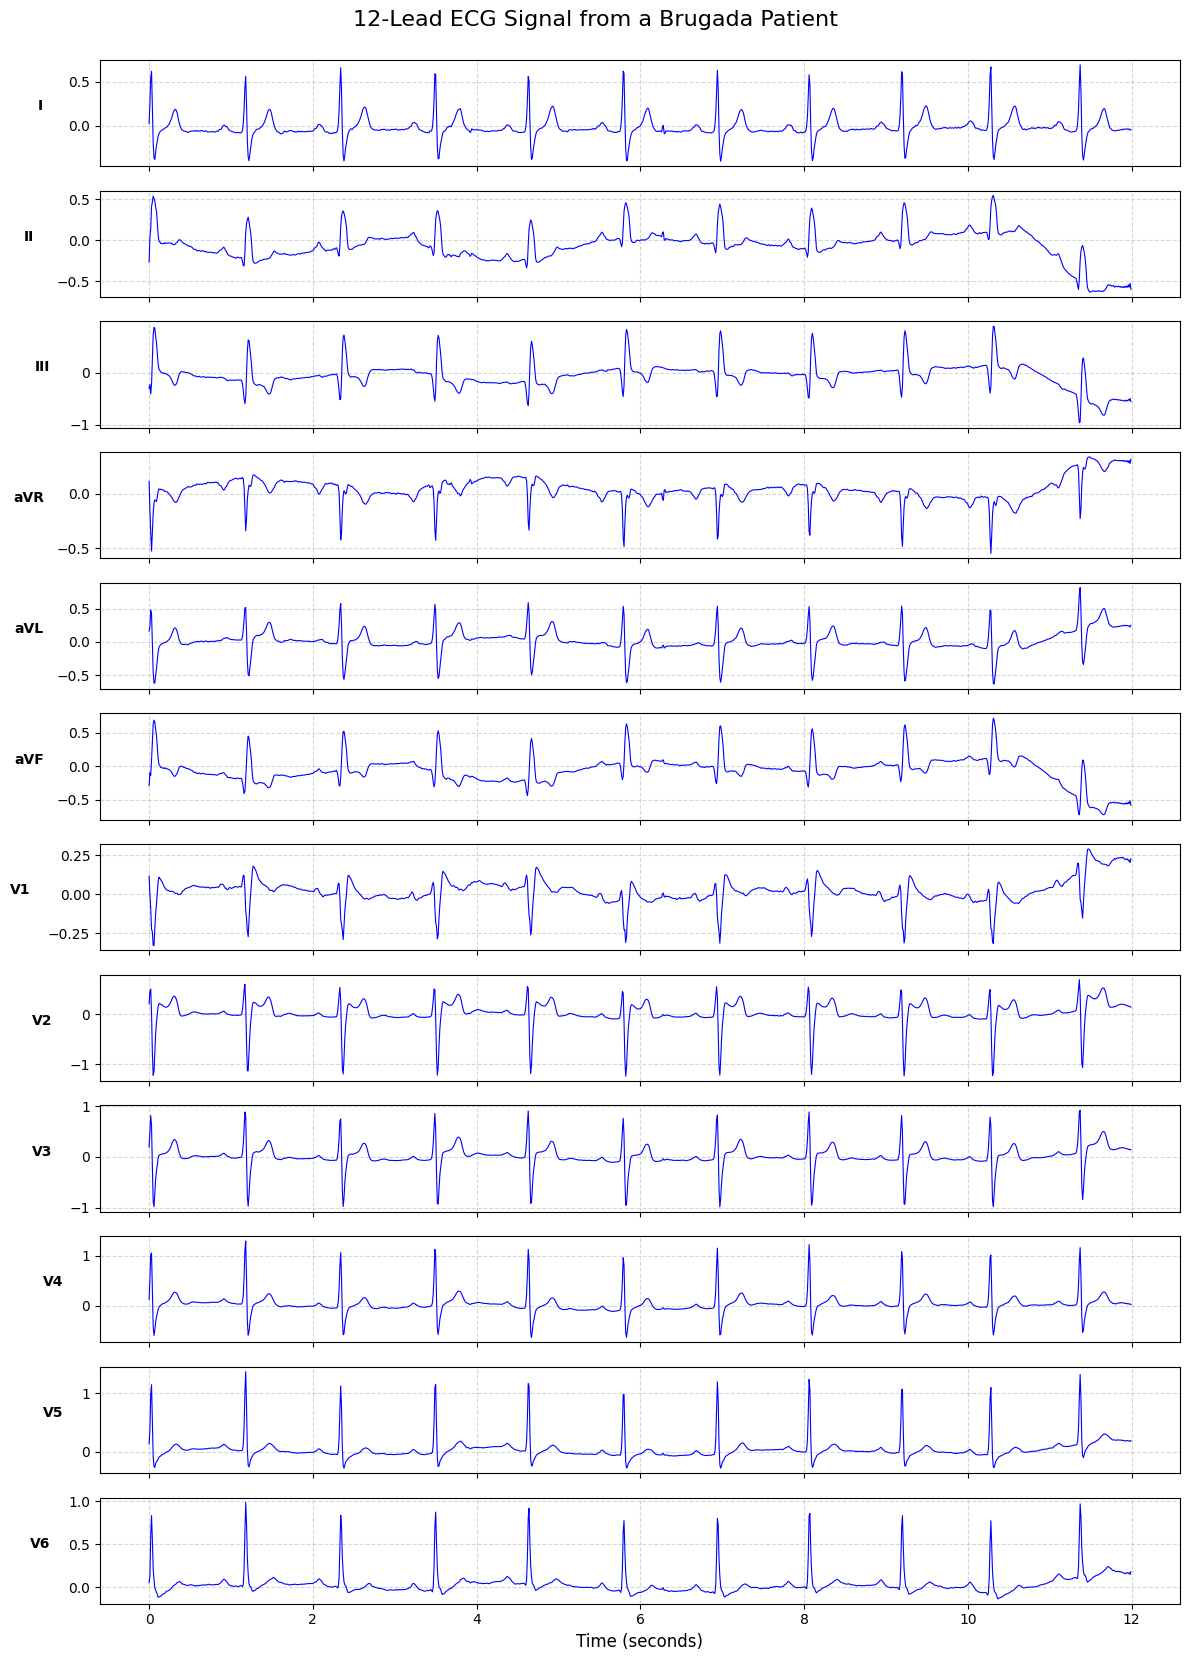

In [206]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Take sample frequency from 'record' object
sampling_freq = record.fs
time_axis = np.arange(signal.shape[0]) / sampling_freq

# 2. Retrieve the names of lead from the records
lead_names = record.sig_name
num_leads = signal.shape[1] 

# 3. Make a subplots
fig, axes = plt.subplots(nrows=num_leads, ncols=1, figsize=(12, 18), sharex=True)

# 4. Do iteration for each leads
for i in range(num_leads):
    axes[i].plot(time_axis, signal[:, i], color='blue', linewidth=0.8)
    axes[i].set_ylabel(lead_names[i], rotation=0, labelpad=20, fontsize=10, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# 5. Configuration
axes[-1].set_xlabel('Time (seconds)', fontsize=12)
fig.suptitle(f"12-Lead ECG Signal from a Brugada Patient", fontsize=16, y=0.92)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [207]:
# Take 3 importance leads because for brugada syndrome we just need these leads
v1 = signal[:, 6]
v2 = signal[:, 7]
v3 = signal[:, 8]

In [208]:
# Removing noise from a signal using a bandpass filter
v1 = bandpass_filter(v1)
v2 = bandpass_filter(v2)
v3 = bandpass_filter(v3)

In [209]:
# Detecting and extracting the peak location index of the R-wave from V1 signal
signals, info = nk.ecg_process(v1, sampling_rate=100)
r_peaks = info["ECG_R_Peaks"]

print(r_peaks[:10])

[ 115  231  347  461  577  691  804  917 1025 1134]


Feature Extraction

In [210]:
# Measuring and extracting morphological characteristics (waveforms) for each heartbeat
st_values = []
slopes = []
qrs_durations = []
t_amplitudes = []
t_polarities = []

for r in r_peaks:
    if r-10 < 0 or r+60 >= len(v1):
        continue

    # Extraction ST Segment
    st = float(v1[r+2] - v1[r-10])
    st_values.append(st)

    # Extraction Slope of ST Segment
    slope = float((v1[r+8] - v1[r+2]) / 6)
    slopes.append(slope)

    # Extraction QRS Duration
    qrs_durations.append(10)

    # Extraction T-wave
    t_wave = v1[r+20:r+50]
    if len(t_wave) > 0:
        t_amp = float(np.max(t_wave))

        t_amplitudes.append(t_amp)

        t_polarities.append(1 if t_amp > 0 else 0)

In [211]:
# Safety Net
if len(st_values) == 0: st_values = [0]
if len(slopes) == 0: slopes = [0]
if len(qrs_durations) == 0: qrs_durations = [0]
if len(t_amplitudes) == 0: t_amplitudes = [0]
if len(t_polarities) == 0: t_polarities = [0]

In [212]:
# Feature Aggregation
features_v1 = {
    "st_mean_V1": float(np.mean(st_values)),
    "st_max_V1": float(np.max(st_values)),
    "slope_mean_V1": float(np.mean(slopes)),
    "qrs_mean_V1": float(np.mean(qrs_durations)),
    "t_amp_mean_V1": float(np.mean(t_amplitudes)),
    "t_polarity_V1": float(np.mean(t_polarities)),
    "mean_V1": float(np.mean(v1)),
    "std_V1": float(np.std(v1)),
    "max_V1": float(np.max(v1)),
    "min_V1": float(np.min(v1))
}

features_v1

{'st_mean_V1': -0.05805808378731092,
 'st_max_V1': 0.011333294352154317,
 'slope_mean_V1': -0.004197589496311141,
 'qrs_mean_V1': 10.0,
 't_amp_mean_V1': 0.04873385125469135,
 't_polarity_V1': 0.9,
 'mean_V1': -0.004239575364715386,
 'std_V1': 0.06889943903507527,
 'max_V1': 0.16456685146693464,
 'min_V1': -0.4235581744135908}

In [213]:
# MAIN FEATURE EXTRACTION LOOP
"""
BATCH DATA EXTRACTION PROCESS
Step inside this loop:
1. Read patient ID from metadata and load the signal record (.dat/.hea).
2. Extract spesific signals for Leads V1, V2, and V3.
3. Apply Bandpass Filter and detect R-Peaks.
4. Extract HRV features (R-R intervals) and wave morphology (ST, Slope, QRS, and T-Wave).
5. Calculate statistical summaries (mean, max, std) for each feature.
6. Append the extracted features and Brugada label to the 'all_data' list.
"""
all_data = []

for i, row in metadata.iterrows():
    patient_id = str(row["patient_id"])
    record_path = f"files/{patient_id}/{patient_id}"

    try:
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal

        leads = {
            "V1": signal[:, 6],
            "V2": signal[:, 7],
            "V3": signal[:, 8]
        }

        patient_features = {}

        for lead_name, lead_signal in leads.items():

            v = lead_signal.astype(np.float32)
            v = bandpass_filter(v)

            # R-peak detection
            _, info = nk.ecg_peaks(v, sampling_rate=100)
            r_peaks = info["ECG_R_Peaks"][:15]

            # R-R Interval
            if len(r_peaks) > 1:
                rr_diff_samples = np.diff(r_peaks)
                rr_intervals = rr_diff_samples * 10.0
                
                rr_mean = float(np.mean(rr_intervals))
                rr_std = float(np.std(rr_intervals))
            else:
                rr_mean = 0.0
                rr_std = 0.0

            st_values = []
            slopes = []
            qrs_durations = []
            t_amplitudes = []
            t_polarities = []

            for r in r_peaks:
                if r-10 < 0 or r+60 >= len(v):
                    continue

                # 1. ST Segment (40-80ms After R)
                st_segment = v[r+4 : r+8] 
                baseline = v[r-10] 
                
                if len(st_segment) > 0:
                    st = float(np.max(st_segment) - baseline) 
                    st_values.append(st)

                # 2. Slope 
                slope = float((v[r+12] - v[r+4]) / 8)
                slopes.append(slope)

                # 3. QRS Duration Proxy
                q_kandidat = v[max(0, r-5):r] 
                s_kandidat = v[r:min(len(v), r+5)] 
                
                if len(q_kandidat) > 0 and len(s_kandidat) > 0:
                    q_idx = np.argmin(q_kandidat)
                    s_idx = np.argmin(s_kandidat)
                    qrs_width = (s_idx + (len(q_kandidat) - q_idx)) * 10
                    qrs_durations.append(float(qrs_width))

                # 4. T-wave (200ms - 500ms After R)
                t_wave = v[r+20:r+50]
                if len(t_wave) > 0:
                    t_amp = float(np.max(t_wave))
                    t_amplitudes.append(t_amp)
                    t_polarities.append(1 if t_amp > 0 else 0)

            if len(st_values) == 0: st_values = [0]
            if len(slopes) == 0: slopes = [0]
            if len(qrs_durations) == 0: qrs_durations = [0]
            if len(t_amplitudes) == 0: t_amplitudes = [0]
            if len(t_polarities) == 0: t_polarities = [0]

            patient_features[f"rr_mean_{lead_name}"] = rr_mean
            patient_features[f"rr_std_{lead_name}"] = rr_std  # Fitur HRV Dasar

            patient_features[f"st_mean_{lead_name}"] = float(np.mean(st_values))
            patient_features[f"st_max_{lead_name}"] = float(np.max(st_values))
            patient_features[f"st_std_{lead_name}"] = float(np.std(st_values))
            patient_features[f"slope_std_{lead_name}"] = float(np.std(slopes))
            patient_features[f"slope_mean_{lead_name}"] = float(np.mean(slopes))
            patient_features[f"qrs_mean_{lead_name}"] = float(np.mean(qrs_durations))
            patient_features[f"t_amp_mean_{lead_name}"] = float(np.mean(t_amplitudes))
            patient_features[f"t_amp_std_{lead_name}"] = float(np.std(t_amplitudes))
            patient_features[f"t_polarity_{lead_name}"] = float(np.mean(t_polarities))

            patient_features[f"mean_{lead_name}"] = float(np.mean(v))
            patient_features[f"std_{lead_name}"] = float(np.std(v))
            patient_features[f"max_{lead_name}"] = float(np.max(v))
            patient_features[f"min_{lead_name}"] = float(np.min(v))

            del v

        # Add Metadata
        patient_features["basal_pattern"] = row["basal_pattern"]
        patient_features["sudden_death"] = row["sudden_death"]
        patient_features["label"] = row["brugada"]

        all_data.append(patient_features)

        # free memory
        del record, signal

    except Exception as e:
        print("Error di:", patient_id, e)
        continue

    if i % 20 == 0:
        print("Processed:", i)

Processed: 0
Processed: 20
Processed: 40
Processed: 60
Processed: 80
Processed: 100
Processed: 120
Processed: 140
Processed: 160
Processed: 180
Processed: 200
Processed: 220
Processed: 240
Processed: 260
Processed: 280
Processed: 300
Processed: 320
Processed: 340
Processed: 360


In [214]:
# Make a DataFrame of each ECG features
df = pd.DataFrame(all_data)
df.head()

,rr_mean_V1,rr_std_V1,st_mean_V1,st_max_V1,st_std_V1,slope_std_V1,slope_mean_V1,qrs_mean_V1,t_amp_mean_V1,t_amp_std_V1,t_polarity_V1,mean_V1,std_V1,max_V1,min_V1,rr_mean_V2,rr_std_V2,st_mean_V2,st_max_V2,st_std_V2,slope_std_V2,slope_mean_V2,qrs_mean_V2,t_amp_mean_V2,t_amp_std_V2,t_polarity_V2,mean_V2,std_V2,max_V2,min_V2,rr_mean_V3,rr_std_V3,st_mean_V3,st_max_V3,st_std_V3,slope_std_V3,slope_mean_V3,qrs_mean_V3,t_amp_mean_V3,t_amp_std_V3,t_polarity_V3,mean_V3,std_V3,max_V3,min_V3,basal_pattern,sudden_death,label
0,1132.222222,26.152450,-0.129740,-0.086848,0.026615,0.003550,0.044705,83.000000,0.045187,0.030813,0.900000,-0.004240,0.068899,0.164567,-0.423558,1132.222222,25.724082,-0.197677,-0.113697,0.060339,0.004538,0.175438,86.000000,0.330177,0.044913,1.000000,-0.006681,0.233500,0.592594,-1.357189,1133.333333,27.487371,-0.161690,-0.073668,0.044189,0.007496,0.121565,84.000000,0.308100,0.050276,1.000000,-0.007900,0.214326,0.894331,-1.166492,1,0,1
1,932.727273,17.627927,-0.506049,-0.351064,0.096389,0.006339,0.215333,82.500000,0.248610,0.030544,1.000000,0.003845,0.297897,0.338251,-1.612305,932.727273,17.627927,0.167913,0.221180,0.039464,0.010491,0.107720,81.666667,0.127997,0.011567,1.000000,0.002281,0.151673,0.278610,-0.875242,932.727273,17.627927,-0.167861,-0.093269,0.049850,0.005738,0.158824,84.166667,0.439860,0.032931,1.000000,0.004814,0.312554,1.327587,-1.359099,0,0,0
2,803.076923,28.388680,0.127888,0.165089,0.015880,0.004288,0.077623,76.153846,0.147483,0.019817,1.000000,0.000843,0.116403,0.190226,-0.606299,803.076923,28.116411,0.070608,0.083898,0.008693,0.009784,0.035685,61.538462,0.356645,0.014499,1.000000,0.002528,0.168607,0.695234,-0.576653,803.076923,28.388680,-0.040305,-0.028823,0.008097,0.011338,0.030996,61.538462,0.291488,0.012972,1.000000,0.002334,0.266860,1.647922,-0.626074,0,0,0
3,847.500000,12.990381,0.136706,0.149289,0.007732,0.015739,0.143169,65.384615,0.063009,0.018188,1.000000,-0.001663,0.210134,0.272505,-1.391121,847.500000,12.332207,0.196971,0.210381,0.006794,0.014929,0.066241,83.076923,0.147629,0.020843,1.000000,-0.000083,0.115011,0.206525,-0.660392,848.461538,12.917581,-0.053358,-0.031967,0.012805,0.001665,0.015102,60.000000,0.404229,0.039853,1.000000,0.001526,0.273805,1.810470,-0.476684,0,0,0
4,784.285714,991.872070,0.038852,0.106395,0.030269,0.010072,-0.000144,34.285714,0.080683,0.074410,0.928571,0.001115,0.084478,0.282798,-0.660347,835.384615,1568.873262,0.048321,0.118217,0.027603,0.003382,0.011931,49.230769,0.151158,0.082435,0.923077,0.001048,0.089986,0.348503,-0.716824,467.692308,295.352562,0.073873,0.222146,0.080668,0.011515,0.027877,48.571429,0.475869,0.279911,0.857143,-0.005666,0.164496,0.881272,-0.904774,0,0,1


In [215]:
# Save the ECG data in numeric for use in the XGBoost model
df.to_csv("ecg_features.csv", index=False)

In [216]:
# Load the ECG features dataset
import pandas as pd

df = pd.read_csv("ecg_features.csv")
df.head()

,rr_mean_V1,rr_std_V1,st_mean_V1,st_max_V1,st_std_V1,slope_std_V1,slope_mean_V1,qrs_mean_V1,t_amp_mean_V1,t_amp_std_V1,t_polarity_V1,mean_V1,std_V1,max_V1,min_V1,rr_mean_V2,rr_std_V2,st_mean_V2,st_max_V2,st_std_V2,slope_std_V2,slope_mean_V2,qrs_mean_V2,t_amp_mean_V2,t_amp_std_V2,t_polarity_V2,mean_V2,std_V2,max_V2,min_V2,rr_mean_V3,rr_std_V3,st_mean_V3,st_max_V3,st_std_V3,slope_std_V3,slope_mean_V3,qrs_mean_V3,t_amp_mean_V3,t_amp_std_V3,t_polarity_V3,mean_V3,std_V3,max_V3,min_V3,basal_pattern,sudden_death,label
0,1132.222222,26.152450,-0.129740,-0.086848,0.026615,0.003550,0.044705,83.000000,0.045187,0.030813,0.900000,-0.004240,0.068899,0.164567,-0.423558,1132.222222,25.724082,-0.197677,-0.113697,0.060339,0.004538,0.175438,86.000000,0.330177,0.044913,1.000000,-0.006681,0.233500,0.592594,-1.357189,1133.333333,27.487371,-0.161690,-0.073668,0.044189,0.007496,0.121565,84.000000,0.308100,0.050276,1.000000,-0.007900,0.214326,0.894331,-1.166492,1,0,1
1,932.727273,17.627927,-0.506049,-0.351064,0.096389,0.006339,0.215333,82.500000,0.248610,0.030544,1.000000,0.003845,0.297897,0.338251,-1.612305,932.727273,17.627927,0.167913,0.221180,0.039464,0.010491,0.107720,81.666667,0.127997,0.011567,1.000000,0.002281,0.151673,0.278610,-0.875242,932.727273,17.627927,-0.167861,-0.093269,0.049850,0.005738,0.158824,84.166667,0.439860,0.032931,1.000000,0.004814,0.312554,1.327587,-1.359099,0,0,0
2,803.076923,28.388680,0.127888,0.165089,0.015880,0.004288,0.077623,76.153846,0.147483,0.019817,1.000000,0.000843,0.116403,0.190226,-0.606299,803.076923,28.116411,0.070608,0.083898,0.008693,0.009784,0.035685,61.538462,0.356645,0.014499,1.000000,0.002528,0.168607,0.695234,-0.576653,803.076923,28.388680,-0.040305,-0.028823,0.008097,0.011338,0.030996,61.538462,0.291488,0.012972,1.000000,0.002334,0.266860,1.647922,-0.626074,0,0,0
3,847.500000,12.990381,0.136706,0.149289,0.007732,0.015739,0.143169,65.384615,0.063009,0.018188,1.000000,-0.001663,0.210134,0.272505,-1.391121,847.500000,12.332207,0.196971,0.210381,0.006794,0.014929,0.066241,83.076923,0.147629,0.020843,1.000000,-0.000083,0.115011,0.206525,-0.660392,848.461538,12.917581,-0.053358,-0.031967,0.012805,0.001665,0.015102,60.000000,0.404229,0.039853,1.000000,0.001526,0.273805,1.810470,-0.476684,0,0,0
4,784.285714,991.872070,0.038852,0.106395,0.030269,0.010072,-0.000144,34.285714,0.080683,0.074410,0.928571,0.001115,0.084478,0.282798,-0.660347,835.384615,1568.873262,0.048321,0.118217,0.027603,0.003382,0.011931,49.230769,0.151158,0.082435,0.923077,0.001048,0.089986,0.348503,-0.716824,467.692308,295.352562,0.073873,0.222146,0.080668,0.011515,0.027877,48.571429,0.475869,0.279911,0.857143,-0.005666,0.164496,0.881272,-0.904774,0,0,1


In [217]:
# Take 2 categories from dataset ("Brugada" and "Normal")
df["label_binary"] = df["label"].apply(lambda x: 1 if x == 1 else 0)

X = df.drop(columns=["label", "label_binary", "basal_pattern"])
y = df["label_binary"]

print(X.shape)

(363, 46)


In [218]:
# Count each categories (without atypical case)
print(y.value_counts())

label_binary
0    294
1     69
Name: count, dtype: int64


In [219]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix
import numpy as np

In [220]:
# To address class imbalance
neg = sum(y == 0)
pos = sum(y == 1)

# addresing imbalances data
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight}")

scale_pos_weight: 4.260869565217392


Splitting Data, Model Implementation, and Evaluate the Model

In [221]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
f1_scores = []

oof_y_true = []
oof_y_pred_proba = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
  print(f"Fold {fold+1}")

  # Splitting Data
  X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
  y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

  # Implementation XGBoost model
  model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1,
    min_child_weight=2,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
  )
  
  # Trains a model
  model.fit(X_train, y_train)

  y_pred_proba = model.predict_proba(X_val)[:, 1]
  y_pred = (y_pred_proba > 0.5).astype(int)

  # Evaluate the model
  auc = roc_auc_score(y_val, y_pred_proba)
  f1 = f1_score(y_val, y_pred)

  auc_scores.append(auc)
  f1_scores.append(f1)

  oof_y_true.extend(y_val)
  oof_y_pred_proba.extend(y_pred_proba)

  print(f"AUC: {auc:.4f} | F1 (t=0.5): {f1:.4f}")

print(f"\nMean AUC (Validation): {np.mean(auc_scores):.4f}")
print(f"Mean F1 (Validation t=0.5): {np.mean(f1_scores):.4f}")

Fold 1
AUC: 0.7663 | F1 (t=0.5): 0.4615
Fold 2
AUC: 0.8838 | F1 (t=0.5): 0.6400
Fold 3
AUC: 0.8838 | F1 (t=0.5): 0.6364
Fold 4
AUC: 0.8596 | F1 (t=0.5): 0.6667
Fold 5
AUC: 0.8253 | F1 (t=0.5): 0.5000

Mean AUC (Validation): 0.8438
Mean F1 (Validation t=0.5): 0.5809


In [222]:
oof_y_true = np.array(oof_y_true)
oof_y_pred_proba = np.array(oof_y_pred_proba)

best_f1 = 0
best_threshold_f1 = 0

target_recall = 0.90
safe_threshold = 0
safe_f1 = 0
safe_recall = 0
safe_npv = 0

print("Comprehensive Final Evaluation (Out-Of-Fold):")

for t in np.arange(0.05, 0.9, 0.01):
    y_pred_t = (oof_y_pred_proba > t).astype(int)

    f1 = f1_score(oof_y_true, y_pred_t)
    recall = recall_score(oof_y_true, y_pred_t)

    tn, fp, fn, tp = confusion_matrix(oof_y_true, y_pred_t).ravel()

    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0

    if f1 > best_f1:
        best_f1 = f1
        best_threshold_f1 = t

    if recall >= target_recall:
        safe_threshold = t
        safe_f1 = f1
        safe_recall = recall
        safe_npv = npv


print(f"1. Accuracy Optimation (F1-Score Balance)")
y_pred_best_f1 = (oof_y_pred_proba > best_threshold_f1).astype(int)
tn, fp, fn, tp = confusion_matrix(oof_y_true, y_pred_best_f1).ravel()
npv_best_f1 = tn / (tn + fn) if (tn + fn) > 0 else 0.0
recall_best_f1 = recall_score(oof_y_true, y_pred_best_f1)

print(f"Best Threshold: {best_threshold_f1:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Best Recall: {recall_best_f1:.4f}")
print(f"Best NPV: {npv_best_f1:.4f}")
print(f"Description: there are {fn} Patients with Brugada Syndrome who were missed\n")

print(f"2. Clinic Optimation (Patient Safety Priority / Recall >= {target_recall * 100}%)")
print(f"Safe Threshold: {safe_threshold:.2f}")
print(f"Safe F1 Score: {safe_f1:.4f}")
print(f"Safe Recall: {safe_recall:.4f}")
print(f"Safe NPV: {safe_npv:.4f}")

tn, fp, fn_safe, tp = confusion_matrix(oof_y_true, (oof_y_pred_proba > safe_threshold).astype(int)).ravel()
print(f"Description : Only {fn_safe} Patients with Brugada Syndrome who were missed. safer to ue in hospitals")

Comprehensive Final Evaluation (Out-Of-Fold):
1. Accuracy Optimation (F1-Score Balance)
Best Threshold: 0.43
Best F1 Score: 0.6131
Best Recall: 0.6087
Best NPV: 0.9085
Description: there are 27 Patients with Brugada Syndrome who were missed

2. Clinic Optimation (Patient Safety Priority / Recall >= 90.0%)
Safe Threshold: 0.05
Safe F1 Score: 0.4392
Safe Recall: 0.9420
Safe NPV: 0.9706
Description : Only 4 Patients with Brugada Syndrome who were missed. safer to ue in hospitals


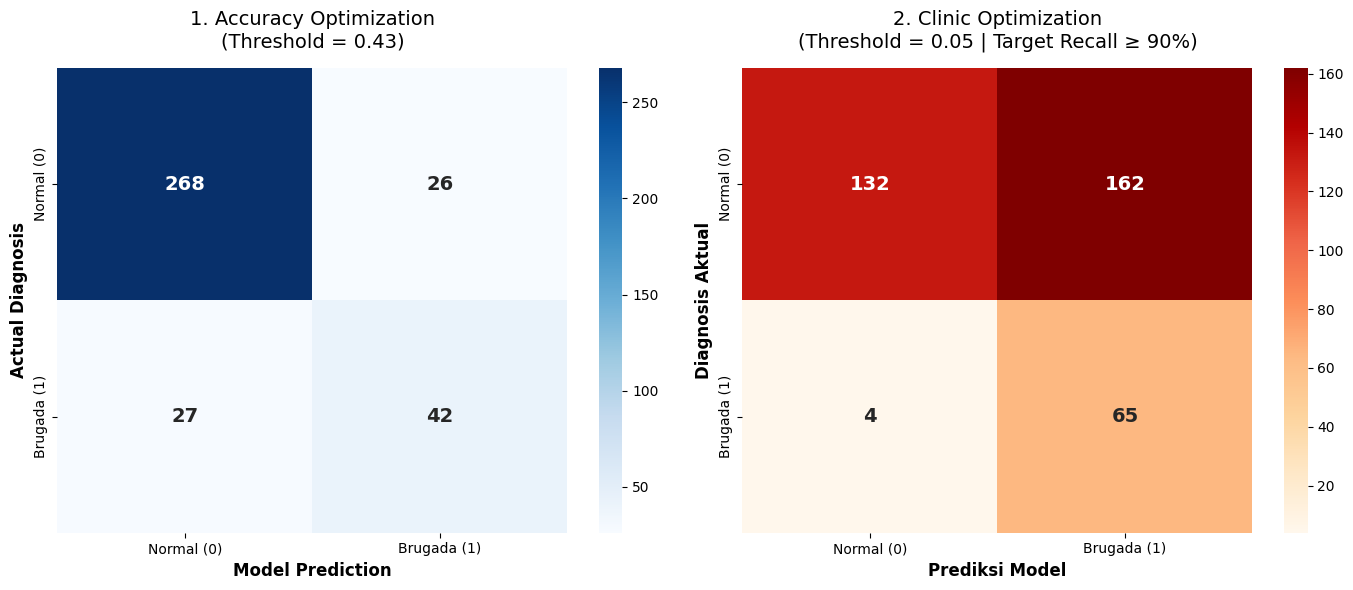

In [223]:
# Visualization of the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_best_f1 = (oof_y_pred_proba > best_threshold_f1).astype(int)
y_pred_safe = (oof_y_pred_proba > safe_threshold).astype(int)

cm_f1 = confusion_matrix(oof_y_true, y_pred_best_f1)
cm_safe = confusion_matrix(oof_y_true, y_pred_safe)

class_labels = ['Normal (0)', 'Brugada (1)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# Confusion Matrix of Accruracy Optimization
sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title(f'1. Accuracy Optimization\n(Threshold = {best_threshold_f1:.2f})', fontsize=14, pad=15)
axes[0].set_xlabel('Model Prediction', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Diagnosis', fontsize=12, fontweight='bold')


# Confusion Matrix of Clinic Optimization
sns.heatmap(cm_safe, annot=True, fmt='d', cmap='OrRd', ax=axes[1], 
            xticklabels=class_labels, yticklabels=class_labels, 
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title(f'2. Clinic Optimization\n(Threshold = {safe_threshold:.2f} | Target Recall ≥ 90%)', fontsize=14, pad=15)
axes[1].set_xlabel('Prediksi Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Diagnosis Aktual', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

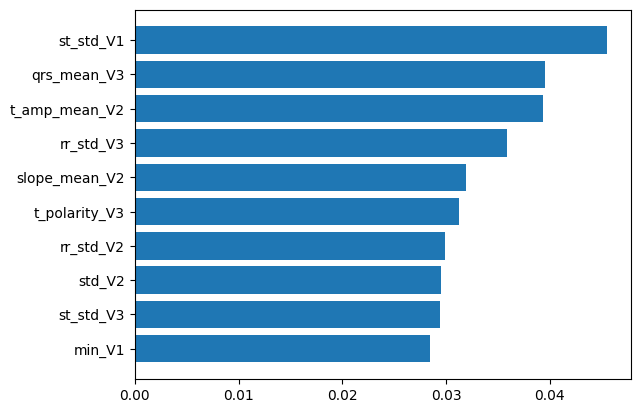

In [224]:
# Feature Importances
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

sorted_idx = np.argsort(importances)[-10:]

plt.barh(features[sorted_idx], importances[sorted_idx])
plt.show()